# EfficientNet — Ré-entraînement corrigé (4 classes)

Ce notebook corrige les 3 causes du problème 'prédit toujours normal' :

1. **Déséquilibre des classes** → WeightedRandomSampler + class weights dans la loss
2. **Ordre des classes** → vérification et sauvegarde explicite avec les métadonnées
3. **Augmentation de données** → transforms enrichis pour généraliser sur les 4 classes

## 1. Installation et imports

In [1]:
!pip install torchvision torch -q

import os
import json
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler, random_split
from torchvision import models, transforms, datasets
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device :', device)


Device : cuda


## 2. Montage Google Drive + configuration

In [5]:
from google.colab import drive
drive.mount('/content/drive')

# Chemin vers ton dataset (dossier avec 4 sous-dossiers de classes)
DATA_PATH   = '/content/drive/MyDrive/deep_polypes'
SAVE_PATH   = '/content/drive/MyDrive/efficientnet_etage2_v2.pt'
META_PATH   = '/content/drive/MyDrive/efficientnet_classes.json'

EPOCHS      = 30
BATCH_SIZE  = 16
LR          = 1e-4
IMG_SIZE    = 224


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 3. Vérification de la distribution des classes

**Etape clé** : avant tout entraînement, on vérifie combien d'images
il y a par classe. Si une classe domine, le modèle prédit toujours
cette classe — c'est très probablement la cause du problème actuel.

Classes (ordre alphabétique) : ['mauvaise_preparation', 'mici', 'normal', 'polype']

  mauvaise_preparation: 131 images
  mici: 67 images
  normal: 275 images
  polype: 105 images

Total : 578 images
Classe majoritaire : normal (275 images)
Classe minoritaire : mici (67 images)


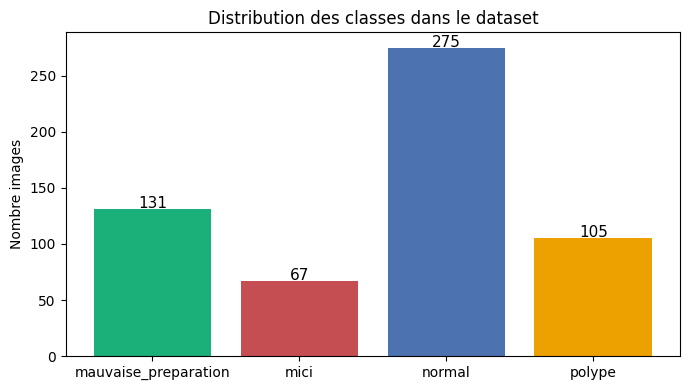

In [6]:
class_names = sorted(os.listdir(DATA_PATH))  # tri alphabétique = ordre ImageFolder
print('Classes (ordre alphabétique) :', class_names)
print()

class_counts = {}
for cls in class_names:
    cls_dir = os.path.join(DATA_PATH, cls)
    n = len([f for f in os.listdir(cls_dir)
             if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
    class_counts[cls] = n
    print(f'  {cls}: {n} images')

print()
total = sum(class_counts.values())
print(f'Total : {total} images')
print(f'Classe majoritaire : {max(class_counts, key=class_counts.get)} '
      f'({max(class_counts.values())} images)')
print(f'Classe minoritaire : {min(class_counts, key=class_counts.get)} '
      f'({min(class_counts.values())} images)')

# Graphique
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(class_names, [class_counts[c] for c in class_names],
              color=['#1baf7a', '#C44E52', '#4C72B0', '#eda100'])
for bar, cls in zip(bars, class_names):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(class_counts[cls]), ha='center', fontsize=11)
ax.set_title('Distribution des classes dans le dataset')
ax.set_ylabel('Nombre images')
plt.tight_layout()
plt.show()


## 4. Transforms avec augmentation de données

**Train** : augmentation forte pour diversifier les exemples vus
par le modèle (rotations, flips, variations de luminosité/couleur).

**Val/Test** : pas d'augmentation — on évalue sur des images 'propres'.

In [7]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(degrees=20),
    transforms.ColorJitter(
        brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1
    ),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

print('Transforms définis.')


Transforms définis.


## 5. Chargement du dataset + split train/val/test

On charge d'abord le dataset complet avec les transforms de validation
(pour le split), puis on applique les transforms d'augmentation
uniquement au sous-ensemble train.

In [8]:
full_dataset = datasets.ImageFolder(root=DATA_PATH, transform=val_transform)
class_names  = full_dataset.classes  # ordre exact d'ImageFolder
num_classes  = len(class_names)

print('Classes (ordre ImageFolder) :', class_names)
print('Nombre de classes :', num_classes)
print('Total images :', len(full_dataset))

# Split 70% train / 15% val / 15% test
n       = len(full_dataset)
n_train = int(0.70 * n)
n_val   = int(0.15 * n)
n_test  = n - n_train - n_val

train_ds, val_ds, test_ds = random_split(
    full_dataset, [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(42)
)

# Appliquer les transforms d'augmentation uniquement sur train
train_ds.dataset = datasets.ImageFolder(
    root=DATA_PATH, transform=train_transform
)

print(f'Train : {n_train} | Val : {n_val} | Test : {n_test}')


Classes (ordre ImageFolder) : ['mauvaise_preparation', 'mici', 'normal', 'polype']
Nombre de classes : 4
Total images : 580
Train : 406 | Val : 87 | Test : 87


## 6. WeightedRandomSampler — correction du déséquilibre

**C'est la correction principale** : au lieu de piocher les images
au hasard (ce qui favorise les classes majoritaires), on donne un
poids plus élevé aux classes sous-représentées pour que le modèle
voit autant d'exemples de chaque classe à chaque epoch.

In [9]:
# Calculer les poids par classe : inversement proportionnel au nombre d'images
train_labels  = [full_dataset.targets[i] for i in train_ds.indices]
class_sample_count = Counter(train_labels)
print('Distribution dans train :', dict(class_sample_count))

weight_per_class = {
    cls_idx: 1.0 / count
    for cls_idx, count in class_sample_count.items()
}
sample_weights = [weight_per_class[label] for label in train_labels]

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, sampler=sampler
)
val_loader  = DataLoader(val_ds,  batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

print('DataLoaders prêts.')
print('Poids par classe :', {
    class_names[k]: round(v, 4) for k, v in weight_per_class.items()
})


Distribution dans train : {0: 91, 2: 191, 3: 76, 1: 48}
DataLoaders prêts.
Poids par classe : {'mauvaise_preparation': 0.011, 'normal': 0.0052, 'polype': 0.0132, 'mici': 0.0208}


## 7. Modèle EfficientNet + class weights dans la loss

**Double correction** : le `WeightedRandomSampler` équilibre
l'échantillonnage, et les `class_weights` dans la `CrossEntropyLoss`
pénalisent plus fortement les erreurs sur les classes rares.

In [10]:
model = models.efficientnet_b0(weights='IMAGENET1K_V1')
model.classifier[1] = nn.Linear(
    model.classifier[1].in_features, num_classes
)
model = model.to(device)

# Class weights pour la loss (inversement proportionnel à la fréquence)
total_train = sum(class_sample_count.values())
class_weights_tensor = torch.tensor(
    [total_train / (num_classes * class_sample_count[i])
     for i in range(num_classes)],
    dtype=torch.float
).to(device)

print('Class weights pour la loss :')
for i, (cls, w) in enumerate(zip(class_names, class_weights_tensor.tolist())):
    print(f'  {cls}: {w:.4f}')

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS, eta_min=1e-6
)


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 193MB/s]


Class weights pour la loss :
  mauvaise_preparation: 1.1154
  mici: 2.1146
  normal: 0.5314
  polype: 1.3355


## 8. Boucle d'entraînement

In [11]:
best_val_acc  = 0.0
train_losses, val_losses, val_accs = [], [], []

for epoch in range(EPOCHS):
    # --- Train ---
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    # --- Val ---
    model.eval()
    val_loss = 0.0
    correct  = 0
    total    = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            val_loss += criterion(outputs, labels).item()
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total   += labels.size(0)

    train_loss = running_loss / len(train_loader)
    val_loss   = val_loss   / len(val_loader)
    val_acc    = correct / total

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    scheduler.step()

    # Sauvegarder le meilleur modèle
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), SAVE_PATH)
        print(f'Epoch {epoch+1:02d}/{EPOCHS} — '
              f'loss: {train_loss:.4f} | val_loss: {val_loss:.4f} | '
              f'val_acc: {val_acc:.2%} ✅ (meilleur)')
    else:
        print(f'Epoch {epoch+1:02d}/{EPOCHS} — '
              f'loss: {train_loss:.4f} | val_loss: {val_loss:.4f} | '
              f'val_acc: {val_acc:.2%}')

print(f'\nMeilleure val_acc : {best_val_acc:.2%}')
print(f'Poids sauvegardés : {SAVE_PATH}')


Epoch 01/30 — loss: 1.1399 | val_loss: 0.9047 | val_acc: 57.47% ✅ (meilleur)
Epoch 02/30 — loss: 0.7182 | val_loss: 0.6511 | val_acc: 66.67% ✅ (meilleur)
Epoch 03/30 — loss: 0.4351 | val_loss: 0.5181 | val_acc: 83.91% ✅ (meilleur)
Epoch 04/30 — loss: 0.2735 | val_loss: 0.4491 | val_acc: 86.21% ✅ (meilleur)
Epoch 05/30 — loss: 0.2105 | val_loss: 0.3044 | val_acc: 90.80% ✅ (meilleur)
Epoch 06/30 — loss: 0.1964 | val_loss: 0.3277 | val_acc: 87.36%
Epoch 07/30 — loss: 0.1678 | val_loss: 0.2433 | val_acc: 90.80%
Epoch 08/30 — loss: 0.1075 | val_loss: 0.2458 | val_acc: 89.66%
Epoch 09/30 — loss: 0.0785 | val_loss: 0.2399 | val_acc: 89.66%
Epoch 10/30 — loss: 0.1456 | val_loss: 0.1417 | val_acc: 93.10% ✅ (meilleur)
Epoch 11/30 — loss: 0.0942 | val_loss: 0.1962 | val_acc: 90.80%
Epoch 12/30 — loss: 0.0905 | val_loss: 0.1768 | val_acc: 91.95%
Epoch 13/30 — loss: 0.0994 | val_loss: 0.1891 | val_acc: 90.80%
Epoch 14/30 — loss: 0.0692 | val_loss: 0.1940 | val_acc: 90.80%
Epoch 15/30 — loss: 0.0724

## 9. Courbes d'apprentissage

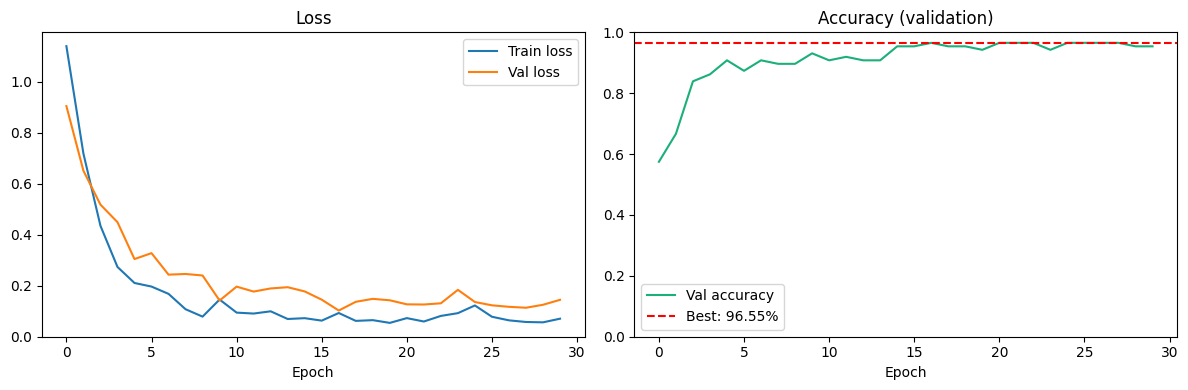

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_losses, label='Train loss')
ax1.plot(val_losses,   label='Val loss')
ax1.set_title('Loss')
ax1.set_xlabel('Epoch')
ax1.legend()

ax2.plot(val_accs, color='#1baf7a', label='Val accuracy')
ax2.axhline(best_val_acc, color='red', linestyle='--',
            label=f'Best: {best_val_acc:.2%}')
ax2.set_title('Accuracy (validation)')
ax2.set_xlabel('Epoch')
ax2.set_ylim(0, 1)
ax2.legend()

plt.tight_layout()
plt.savefig('courbes_entrainement.png', dpi=150, bbox_inches='tight')
plt.show()


## 10. Évaluation sur le jeu de test + matrice de confusion

=== RAPPORT DE CLASSIFICATION ===
                      precision    recall  f1-score   support

mauvaise_preparation       0.95      1.00      0.97        18
                mici       0.88      1.00      0.93         7
              normal       1.00      0.98      0.99        44
              polype       1.00      0.94      0.97        18

            accuracy                           0.98        87
           macro avg       0.96      0.98      0.97        87
        weighted avg       0.98      0.98      0.98        87



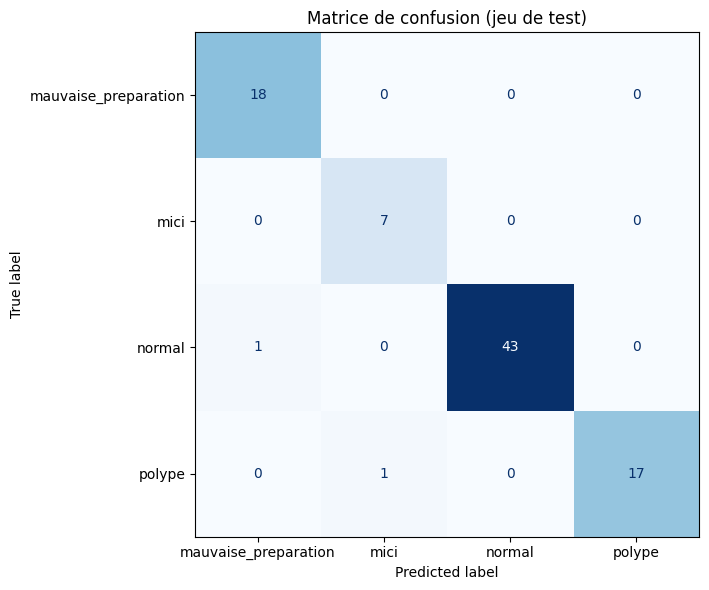

In [13]:
# Charger le meilleur modèle sauvegardé
model.load_state_dict(torch.load(SAVE_PATH, map_location=device))
model.eval()

y_true, y_pred = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)
        y_true.extend(labels.numpy())
        y_pred.extend(preds.cpu().numpy())

print('=== RAPPORT DE CLASSIFICATION ===')
print(classification_report(y_true, y_pred, target_names=class_names))

# Matrice de confusion
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Matrice de confusion (jeu de test)')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


## 11. Sauvegarde des métadonnées de classes

**Etape critique** : on sauvegarde l'ordre exact des classes dans
un fichier JSON. Cela évite le problème d'inversion d'étiquettes
entre l'entraînement et l'app Streamlit/backend.

In [14]:
meta = {
    'class_names': class_names,
    'num_classes': num_classes,
    'model': 'efficientnet_b0',
    'img_size': IMG_SIZE,
    'normalize_mean': [0.485, 0.456, 0.406],
    'normalize_std':  [0.229, 0.224, 0.225],
}

with open(META_PATH, 'w') as f:
    json.dump(meta, f, indent=2)

print('Métadonnées sauvegardées :', META_PATH)
print(json.dumps(meta, indent=2))


Métadonnées sauvegardées : /content/drive/MyDrive/efficientnet_classes.json
{
  "class_names": [
    "mauvaise_preparation",
    "mici",
    "normal",
    "polype"
  ],
  "num_classes": 4,
  "model": "efficientnet_b0",
  "img_size": 224,
  "normalize_mean": [
    0.485,
    0.456,
    0.406
  ],
  "normalize_std": [
    0.229,
    0.224,
    0.225
  ]
}


## 12. Test rapide sur une image

Vérifie que le modèle chargé depuis le fichier `.pt` prédit
correctement avant de le déployer dans l'app.

In [15]:
import json
from PIL import Image

# Charger les métadonnées
with open(META_PATH) as f:
    meta = json.load(f)

inference_transform = transforms.Compose([
    transforms.Resize((meta['img_size'], meta['img_size'])),
    transforms.ToTensor(),
    transforms.Normalize(meta['normalize_mean'], meta['normalize_std']),
])

def predict_image(img_path):
    img    = Image.open(img_path).convert('RGB')
    tensor = inference_transform(img).unsqueeze(0).to(device)
    with torch.no_grad():
        out   = model(tensor)
        probs = torch.softmax(out, dim=1)[0]
        conf, idx = torch.max(probs, dim=0)
    print(f'Classe predite : {meta["class_names"][idx.item()]} '
          f'(confiance : {conf.item():.2%})')
    for i, cls in enumerate(meta['class_names']):
        print(f'  {cls}: {probs[i].item():.2%}')

# Test sur une image de chaque classe
for cls in meta['class_names']:
    cls_dir = os.path.join(DATA_PATH, cls)
    img_file = next(f for f in os.listdir(cls_dir)
                    if f.lower().endswith(('.jpg', '.jpeg', '.png')))
    print(f'\n[Vraie classe: {cls}]')
    predict_image(os.path.join(cls_dir, img_file))



[Vraie classe: mauvaise_preparation]
Classe predite : mauvaise_preparation (confiance : 96.06%)
  mauvaise_preparation: 96.06%
  mici: 0.38%
  normal: 3.50%
  polype: 0.06%

[Vraie classe: mici]
Classe predite : mici (confiance : 99.93%)
  mauvaise_preparation: 0.02%
  mici: 99.93%
  normal: 0.03%
  polype: 0.02%

[Vraie classe: normal]
Classe predite : normal (confiance : 99.37%)
  mauvaise_preparation: 0.31%
  mici: 0.15%
  normal: 99.37%
  polype: 0.17%

[Vraie classe: polype]
Classe predite : polype (confiance : 99.95%)
  mauvaise_preparation: 0.02%
  mici: 0.03%
  normal: 0.00%
  polype: 99.95%


## 13. Mise à jour de app2.py / backend

Une fois les poids sauvegardés, mets à jour ces deux chemins :

**Dans `app2.py` (Streamlit) :**
```python
EFFICIENTNET_PATH = 'weights/efficientnet_etage2_v2.pt'
CLASS_NAMES = ['mauvaise_preparation', 'mici', 'normal', 'polype']  # ordre exact
```

**Dans `backend/main.py` (FastAPI) :**
```python
WEIGHTS_PATH = 'weights/efficientnet_etage2_v2.pt'
CLASS_NAMES  = ['mauvaise_preparation', 'mici', 'normal', 'polype']
```

